Polynomial degree: 3
Coefficients (including bias term):
113.76803676836087 [  0.         -15.53830387   1.34333191  -0.03032088]


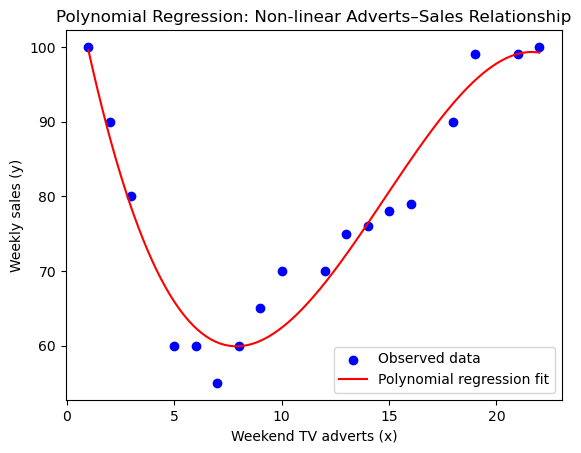

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Data
x = np.array([1, 2, 3, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 18, 19, 21, 22], dtype=float)
y = np.array([100, 90, 80, 60, 60, 55, 60, 65, 70, 70, 75, 76, 78, 79, 90, 99, 99, 100], dtype=float)

X = x.reshape(-1, 1)

# Polynomial feature expansion: degree 2 or 3
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=True)
X_poly = poly.fit_transform(X)  # creates Vandermonde-like matrix [1, x, x^2, ..., x^degree]

# Fit OLS in the expanded feature space
model = LinearRegression()
model.fit(X_poly, y)

# Predictions on a dense grid
x_grid = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
x_grid_poly = poly.transform(x_grid)
y_grid = model.predict(x_grid_poly)

print(f"Polynomial degree: {degree}")
print("Coefficients (including bias term):")
print(model.intercept_, model.coef_)

# Plot data and polynomial curve
plt.scatter(x, y, color='blue', label='Observed data')
plt.plot(x_grid, y_grid, color='red', label='Polynomial regression fit')
plt.xlabel('Weekend TV adverts (x)')
plt.ylabel('Weekly sales (y)')
plt.title('Polynomial Regression: Non-linear Adverts–Sales Relationship')
plt.legend()
plt.show()